In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Load Data

In [58]:
BASE_PATH = "../data/raw/"

df_match = pd.read_csv(BASE_PATH + "gold_match.csv")
df_tickets = pd.read_csv(BASE_PATH + "gold_match_tickets.csv")
df_context = pd.read_csv(BASE_PATH + "gold_match_context.csv")

df_articles = pd.read_csv(
    BASE_PATH + "gold_belga_press_articles.csv",
    engine="python",
    on_bad_lines="skip"
)

df_trends = pd.read_csv(BASE_PATH + "gold_google_trends_daily.csv")

Megre Base Dataset

In [59]:
# Merge without duplicate match_date
df = df_match.merge(df_tickets, on="match_id", how="left")

df = df.merge(
    df_context.drop(columns=["match_date"], errors="ignore"),
    on="match_id",
    how="left"
)

# Only home matches
df = df[df["is_home_match"] == True]

# Target variable
df["attendance"] = df["tickets_scanned"]

Minimal Cleaning

In [60]:
# Remove rows without attendance
df = df[df["attendance"].notna()]

# Fill missing values
df.fillna({
    "weather_score": 0,
    "is_weekend": 0
}, inplace=True)

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,is_midweek,academic_year,academic_week,is_public_holiday,public_holiday_name,is_school_holiday_flanders,school_holiday_name,pct_free_tickets,campaign_motto,attendance
1,d256yo3eng04m0fu7b4sl7wno,2022-07-30,18:15:00,2022-07-30Z,16:15:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,False,2021/2022,48,False,NaN,True,Summer Holiday,13.9,NaN,5565.0
3,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18:30:00,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,False,2021/2022,50,False,NaN,True,Summer Holiday,8.3,NaN,7440.0
5,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18:15:00,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,False,2021/2022,52,False,NaN,True,Summer Holiday,14.8,NaN,4489.0
7,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20:45:00,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,False,2022/2023,2,False,NaN,False,NaN,68.7,NaN,4508.0
9,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,16:00:00,2022-10-01Z,14:00:00Z,10.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,False,2022/2023,5,False,NaN,False,NaN,7.5,NaN,6290.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,ecz9iyxyc5ira9n59m8cp3bis,2025-12-21,19:15:00,2025-12-21Z,18:15:00Z,19.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2025/2026,16lkdpoccbh056r0v0bordo2c,...,False,2025/2026,16,False,NaN,False,NaN,48.8,NaN,5812.0
135,enw1n6mhkzvb6uptwhzs4gowk,2026-01-24,20:45:00,2026-01-24Z,19:45:00Z,22.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2025/2026,16lkdpoccbh056r0v0bordo2c,...,False,2025/2026,21,False,NaN,False,NaN,42.3,NaN,5322.0
136,eqncupz92qy89z9bxks1e0t90,2026-02-01,19:15:00,2026-02-01Z,18:15:00Z,23.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2025/2026,16lkdpoccbh056r0v0bordo2c,...,False,2025/2026,22,False,NaN,False,NaN,55.1,NaN,5971.0
138,ewgb5fczpfa71pfzihlip6yok,2026-02-14,16:00:00,2026-02-14Z,15:00:00Z,25.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2025/2026,16lkdpoccbh056r0v0bordo2c,...,False,2025/2026,24,False,NaN,False,NaN,44.4,NaN,5137.0


Date Conversion

In [61]:
df["match_date"] = pd.to_datetime(df["match_date"])
df_articles["date"] = pd.to_datetime(df_articles["date"])
df_trends["date"] = pd.to_datetime(df_trends["date"])

# Media Feature Engineering

In [62]:
def smart_sentiment(text):
    if pd.isna(text):
        return 0
    
    text = text.lower()
    
    positive = ["win", "victory", "strong", "excellent", "good", "success"]
    negative = ["loss", "defeat", "injury", "crisis", "bad", "poor"]
    
    score = 0
    
    for w in positive:
        if w in text:
            score += 1
            
    for w in negative:
        if w in text:
            score -= 1
    
    return score

df_articles["sentiment"] = df_articles["title"].apply(smart_sentiment)

Event Detection

In [63]:
def detect_events(text):
    if pd.isna(text):
        return {"coach": 0, "transfer": 0, "performance": 0}
    
    text = text.lower()
    
    return {
        "coach": int("coach" in text or "manager" in text),
        "transfer": int("transfer" in text or "sign" in text),
        "performance": int("win" in text or "victory" in text or "points" in text)
    }

event_df = df_articles["title"].apply(detect_events).apply(pd.Series)

df_articles = pd.concat([df_articles, event_df], axis=1)

Link Articles to Matches

In [64]:
df_articles = df_articles.merge(
    df[["match_id", "match_date"]],
    on="match_id",
    how="left"
)

df_articles["days_before_match"] = (
    df_articles["match_date"] - df_articles["date"]
).dt.days

# Keep relevant articles only
df_articles = df_articles[
    (df_articles["days_before_match"] >= 0) &
    (df_articles["days_before_match"] <= 30)
]

Aggregate New Features

In [65]:
news_features = df_articles.groupby("match_id").agg(
    articles_count=("article_id", "count"),
    avg_sentiment=("sentiment", "mean"),
    coach_events=("coach", "sum"),
    transfer_events=("transfer", "sum"),
    performance_events=("performance", "sum"),
    articles_last_7_days=("days_before_match", lambda x: (x <= 7).sum())
).reset_index()

Merge News Features

In [66]:
df = df.merge(news_features, on="match_id", how="left")

df[[
    "articles_count",
    "avg_sentiment",
    "coach_events",
    "transfer_events",
    "performance_events",
    "articles_last_7_days"
]] = df[[
    "articles_count",
    "avg_sentiment",
    "coach_events",
    "transfer_events",
    "performance_events",
    "articles_last_7_days"
]].fillna(0)

Google Trends Features

In [67]:
trend_features = df_trends.groupby("match_id").agg(
    avg_trend=("ohl_interest", "mean"),
    max_trend=("ohl_interest", "max")
).reset_index()

df = df.merge(trend_features, on="match_id", how="left")

df[["avg_trend", "max_trend"]] = df[["avg_trend", "max_trend"]].fillna(0)

Buzz Score

In [68]:
df["buzz_score"] = (
    0.3 * df["articles_count"] +
    0.2 * df["avg_sentiment"] +
    0.2 * df["performance_events"] +
    0.3 * df["avg_trend"]
)

Correlation Analysis

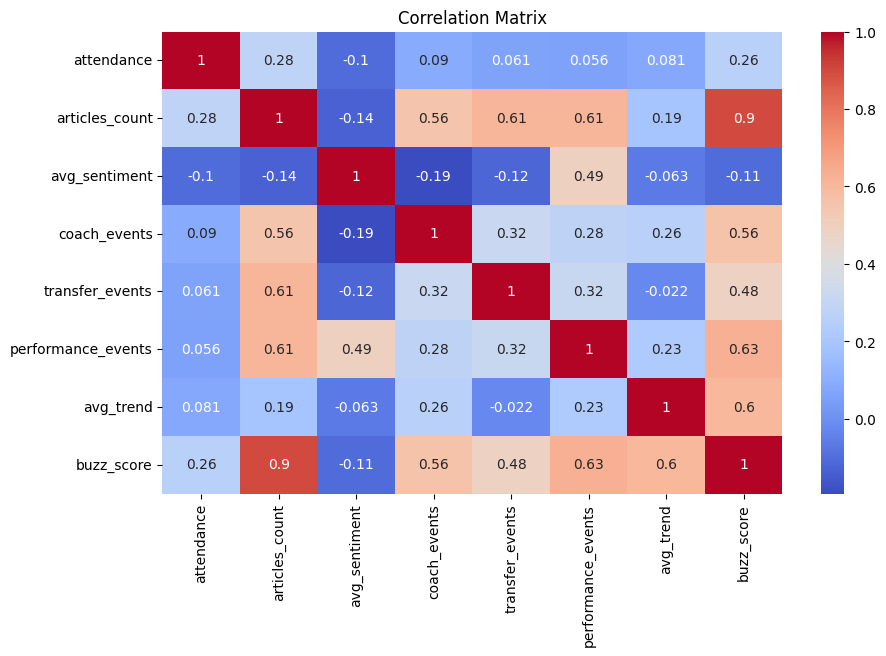

In [69]:
features = [
    "attendance",
    "articles_count",
    "avg_sentiment",
    "coach_events",
    "transfer_events",
    "performance_events",
    "avg_trend",
    "buzz_score"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Scatter Plots

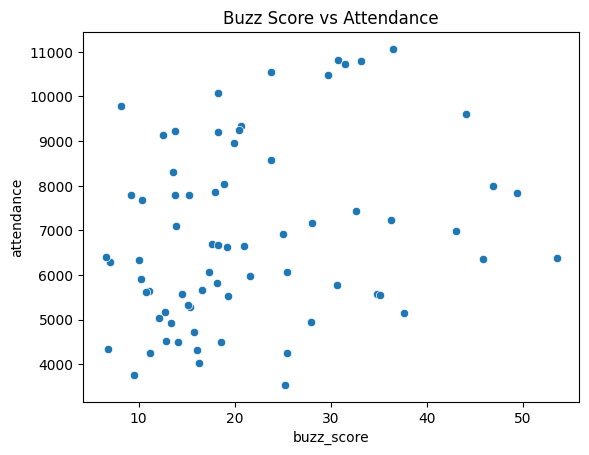

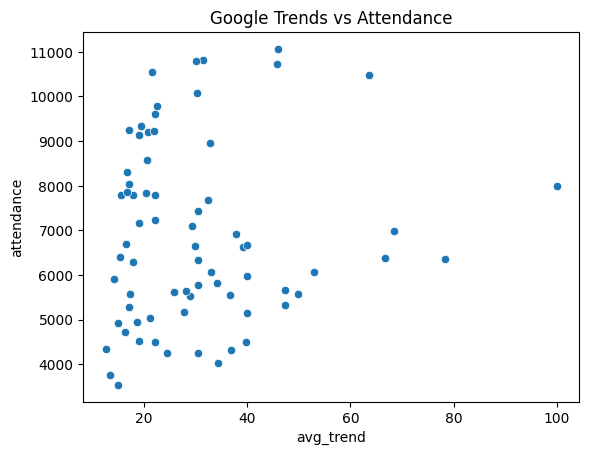

In [70]:
sns.scatterplot(x=df["buzz_score"], y=df["attendance"])
plt.title("Buzz Score vs Attendance")
plt.show()

sns.scatterplot(x=df["avg_trend"], y=df["attendance"])
plt.title("Google Trends vs Attendance")
plt.show()

Model

In [71]:
FEATURES = [
    "articles_count",
    "avg_sentiment",
    "coach_events",
    "transfer_events",
    "performance_events",
    "avg_trend",
    "buzz_score",
    "is_weekend",
    "weather_score"
]

df_model = df[FEATURES + ["attendance"]].dropna()

X = df_model[FEATURES]
y = df_model["attendance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Linear Regression

In [72]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

preds_lin = lin_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds_lin))
print("R2:", r2_score(y_test, preds_lin))

coeffs = pd.Series(lin_model.coef_, index=X.columns)
print("\nCoefficients:")
print(coeffs.sort_values(ascending=False))

MAE: 2509.9136082632144
R2: -5.672754634580659

Coefficients:
is_weekend            869.767403
avg_sentiment         641.222085
buzz_score            108.321659
avg_trend              20.168887
articles_count          3.923212
weather_score         -32.700961
transfer_events      -110.827359
performance_events   -135.751940
coach_events         -216.975753
dtype: float64


Random Forest

In [73]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

preds_rf = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds_rf))
print("R2:", r2_score(y_test, preds_rf))

MAE: 1850.0479999999998
R2: -2.700089937137208


Feature Importance

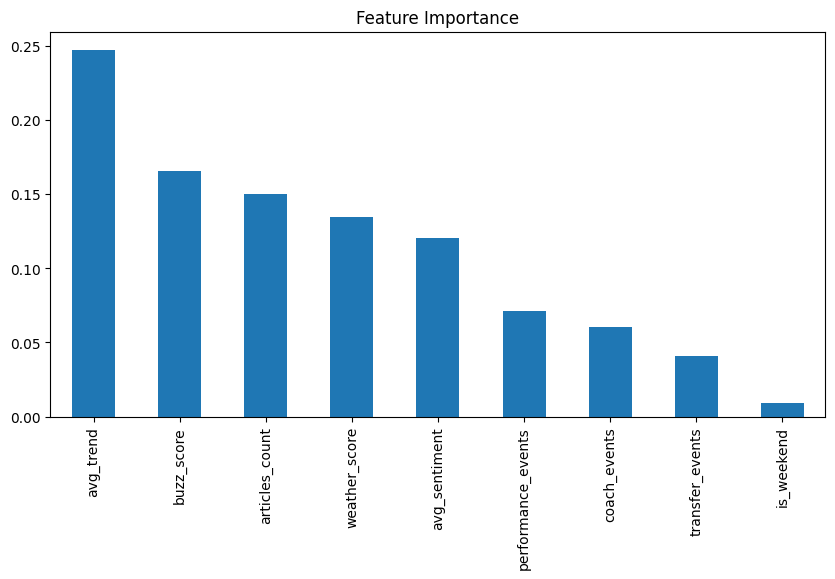

avg_trend             0.247311
buzz_score            0.165936
articles_count        0.150127
weather_score         0.134360
avg_sentiment         0.120224
performance_events    0.071257
coach_events          0.060511
transfer_events       0.040817
is_weekend            0.009457
dtype: float64


In [74]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

print(importances)

# Conclusion

1. Media features alone cannot accurately predict attendance
2. Strongest relationships with attendance:
articles_count → 0.28
buzz_score → 0.26
avg_trend → ~0.08 (weak)

    Interpretation:

    Media has a positive but weak-to-moderate effect
3. Sentiment:
avg_sentiment → -0.1
    Translation:

    - Sentiment is basically noise

Fans care about buzz, not tone

## RETRAIN

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

Data sorted

In [229]:
df = df.sort_values("match_date").copy()
df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")

Basic data/time features

In [230]:
df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")

df["kickoff_hour"] = pd.to_datetime(
    df["kickoff_time_local"], format="%H:%M:%S", errors="coerce"
).dt.hour

df["kickoff_is_evening"] = (df["kickoff_hour"] >= 18).astype(int)
df["month"] = df["match_date"].dt.month

Sporting form features

In [ ]:
result_map = {"W": 3, "D": 1, "L": 0}
df["result_points"] = df["result_home"].map(result_map).fillna(0)

df["goal_diff"] = (df["goals_home_ft"] - df["goals_away_ft"]).fillna(0)

df["form_last_3"] = df["result_points"].shift(1).rolling(3, min_periods=1).sum()
df["form_last_5"] = df["result_points"].shift(1).rolling(5, min_periods=1).sum()

df["goal_diff_last_3"] = df["goal_diff"].shift(1).rolling(3, min_periods=1).mean()
df["goal_diff_last_5"] = df["goal_diff"].shift(1).rolling(5, min_periods=1).mean()

Attendance Lag Features

In [ ]:
df["attendance_last_game"] = df["tickets_scanned"].shift(1)

df["attendance_last_3"] = (
    df["tickets_scanned"]
    .shift(1)
    .rolling(3, min_periods=1)
    .mean()
)

df["attendance_trend"] = (
    df["tickets_scanned"]
    .shift(1)
    .rolling(5, min_periods=1)
    .mean()
)

df["rolling_std_attendance"] = (
    df["tickets_scanned"]
    .shift(1)
    .rolling(5, min_periods=1)
    .std()
)

Opponent strength / popularity features

In [ ]:
df["opponent_avg_attendance"] = df.groupby("away_team")["tickets_scanned"].transform("mean")

df["opponent_recent_attendance"] = (
    df.groupby("away_team")["tickets_scanned"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

Macth Importance

In [235]:
df["big_match_score"] = (
    df["is_big_opponent"] * 2 +
    (df["matchday"] > 25).astype(int) +
    (df["attendance_last_3"] > df["attendance_last_3"].median()).astype(int)
)

Team Strength Proxy

In [236]:
df["team_strength_proxy"] = df["form_last_5"] + df["goal_diff_last_5"]

Fill Known Numeric Cols

In [237]:
fill_cols = [
    "weather_score", "weather_temp_mean_c",
    "weather_precipitation_mm", "weather_windspeed_max_kmh",
    "articles_count", "avg_sentiment",
    "coach_events", "transfer_events",
    "performance_events", "articles_last_7_days",
    "avg_trend", "max_trend", "buzz_score"
]

for col in fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

One Hot Encoding

In [238]:
categorical_cols = [
    col for col in ["away_team", "stage", "competition_name", "weekday_name", "weather_description"]
    if col in df.columns
]

df_model = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Feature List 

In [239]:
base_features = [
    "matchday", "kickoff_hour", "kickoff_is_evening", "month",
    "is_weekend", "is_midweek", "is_public_holiday", "is_school_holiday_flanders",

    "form_last_3", "form_last_5",
    "goal_diff_last_3", "goal_diff_last_5",
    "team_strength_proxy",

    "attendance_last_game", "attendance_last_3", "attendance_trend",

    "is_big_opponent", "opponent_recent_attendance", "stage_avg_attendance",
    "is_top_match" "rolling_std_attendance", "attendance_suprised",

    "weather_score", "weather_temp_mean_c",
    "weather_precipitation_mm", "weather_windspeed_max_kmh",

    "articles_count", "avg_sentiment",
    "coach_events", "transfer_events", "performance_events",
    "articles_last_7_days", "avg_trend", "max_trend", "buzz_score"
]

existing_base_features = [c for c in base_features if c in df_model.columns]

dummy_features = [
    c for c in df_model.columns
    if c.startswith("away_team_")
    or c.startswith("stage_")
    or c.startswith("competition_name_")
    or c.startswith("weekday_name_")
    or c.startswith("weather_description_")
]

features = existing_base_features + dummy_features

target = "tickets_scanned"

df_model = df_model[features + [target]].copy()
df_model = df_model.dropna(subset=[target]).fillna(0)

Final Clean 

In [240]:
X = df_model[features]
X = X.select_dtypes(include=np.number)
y = df_model[target]

Time Series CV

In [241]:
tscv = TimeSeriesSplit(n_splits=3)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )
}

results = []

for model_name, model in models.items():
    fold_mae, fold_rmse, fold_r2 = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, preds))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
        fold_r2.append(r2_score(y_test, preds))

    results.append({
        "model": model_name,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2)
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print(results_df)


              model          MAE         RMSE        R2
1      RandomForest  1476.853835  1781.746718 -0.304927
2  GradientBoosting  1290.683923  1616.902383 -0.367581
0  LinearRegression  3168.823714  3604.608157 -3.759370


Final Train

In [242]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

best_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

print("\nFINAL RESULTS")
print("MAE:", round(mean_absolute_error(y_test, preds), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 2))
print("R2:", round(r2_score(y_test, preds), 4))


FINAL RESULTS
MAE: 1227.03
RMSE: 1448.1
R2: -0.9711


Feature Importance


Top Features:
attendance_last_game          0.305183
attendance_trend              0.116454
matchday                      0.071403
attendance_last_3             0.068449
avg_trend                     0.063784
buzz_score                    0.063159
month                         0.047737
goal_diff_last_5              0.042564
is_big_opponent               0.039646
opponent_recent_attendance    0.037420
max_trend                     0.032107
avg_sentiment                 0.024997
weather_score                 0.024156
articles_last_7_days          0.011873
performance_events            0.011542
dtype: float64


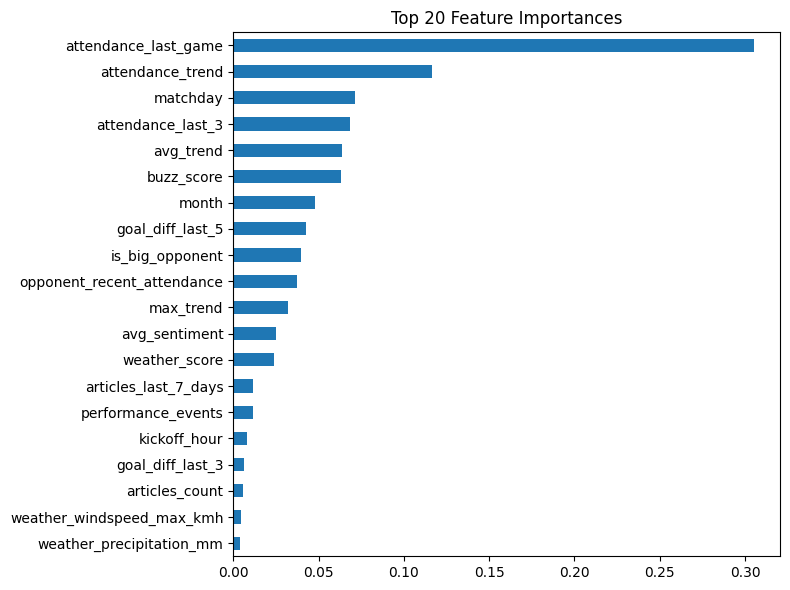

In [243]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Features:")
print(importances.head(15))

plt.figure(figsize=(8,6))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

Plot

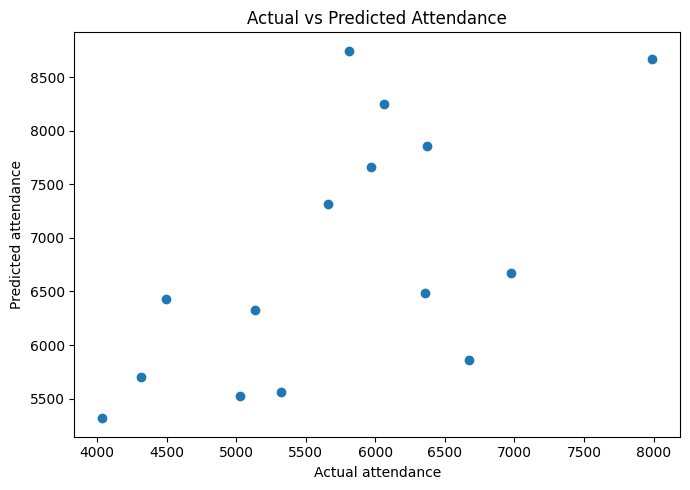

In [244]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, preds)
plt.xlabel("Actual attendance")
plt.ylabel("Predicted attendance")
plt.title("Actual vs Predicted Attendance")
plt.tight_layout()
plt.show()